<a href="https://colab.research.google.com/github/jrdndj/ImproVisAR-PilotPlots/blob/main/Study3_keypress_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-6-0a891440f377>:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_changes = df.groupby(['Condition', 'Task', 'Participant']).apply(calculate_pct_change)


1. Overall Engagement Statistics:
                     Keypresses              
                           mean     std count
Condition Task                               
AR        QuesAns        879.83  447.99     6
          Variations    1560.33  956.02     6
Sheets    QuesAns        767.67  225.24     6
          Variations    1097.83   67.57     6

2. Percentage Changes by Condition and Task:
                       mean    std
Condition Task                    
AR        QuesAns     -8.72  49.58
          Variations -13.26  47.91
Sheets    QuesAns     -8.03  38.19
          Variations   2.85  12.92

3. Individual Participant Changes:
Condition        AR             Sheets           
Task        QuesAns Variations QuesAns Variations
Participant                                      
T001          28.44      20.75     NaN        NaN
T002            NaN        NaN   -1.63      -5.65
T003          10.42       7.52     NaN        NaN
T004            NaN        NaN  -49.00      17.72
T0

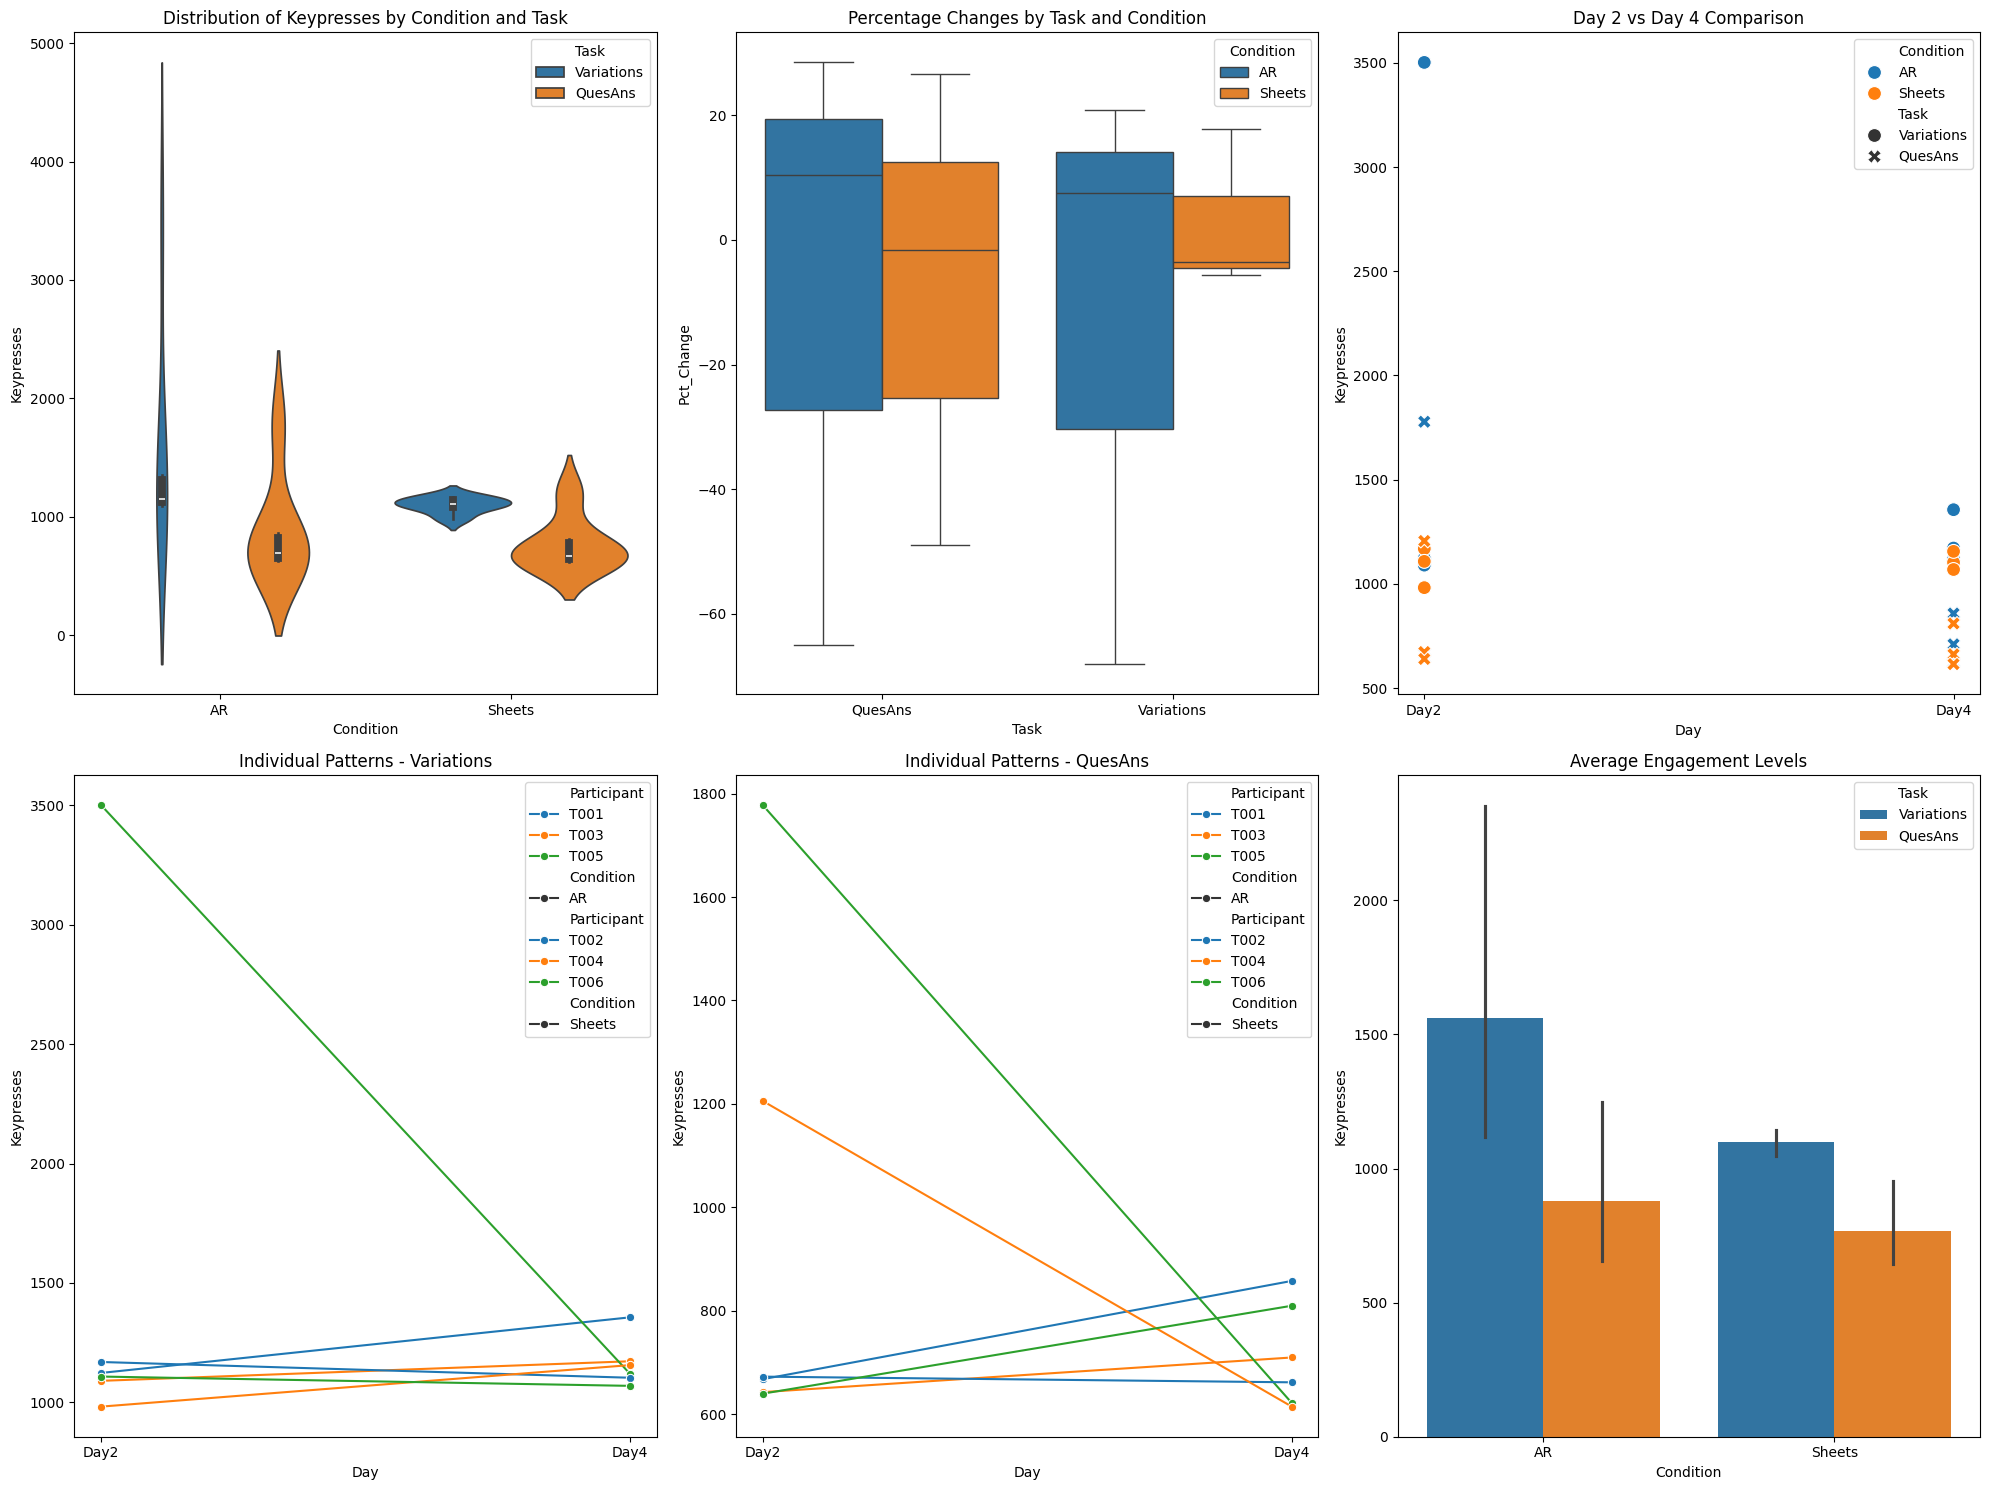

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Create structured data
data = []
for row in [
    # AR Condition Variations
    ('AR', 'Variations', 'T001', 'Day2', 1123), ('AR', 'Variations', 'T001', 'Day4', 1356),
    ('AR', 'Variations', 'T003', 'Day2', 1090), ('AR', 'Variations', 'T003', 'Day4', 1172),
    ('AR', 'Variations', 'T005', 'Day2', 3502), ('AR', 'Variations', 'T005', 'Day4', 1119),
    # AR Condition QuesAns
    ('AR', 'QuesAns', 'T001', 'Day2', 668), ('AR', 'QuesAns', 'T001', 'Day4', 858),
    ('AR', 'QuesAns', 'T003', 'Day2', 643), ('AR', 'QuesAns', 'T003', 'Day4', 710),
    ('AR', 'QuesAns', 'T005', 'Day2', 1778), ('AR', 'QuesAns', 'T005', 'Day4', 622),
    # Sheets Condition Variations
    ('Sheets', 'Variations', 'T002', 'Day2', 1169), ('Sheets', 'Variations', 'T002', 'Day4', 1103),
    ('Sheets', 'Variations', 'T004', 'Day2', 982), ('Sheets', 'Variations', 'T004', 'Day4', 1156),
    ('Sheets', 'Variations', 'T006', 'Day2', 1108), ('Sheets', 'Variations', 'T006', 'Day4', 1069),
    # Sheets Condition QuesAns
    ('Sheets', 'QuesAns', 'T002', 'Day2', 673), ('Sheets', 'QuesAns', 'T002', 'Day4', 662),
    ('Sheets', 'QuesAns', 'T004', 'Day2', 1206), ('Sheets', 'QuesAns', 'T004', 'Day4', 615),
    ('Sheets', 'QuesAns', 'T006', 'Day2', 640), ('Sheets', 'QuesAns', 'T006', 'Day4', 810),
]:
    data.append({
        'Condition': row[0],
        'Task': row[1],
        'Participant': row[2],
        'Day': row[3],
        'Keypresses': row[4]
    })

df = pd.DataFrame(data)

# Calculate percentage changes
def calculate_pct_change(group):
    return ((group[group['Day'] == 'Day4']['Keypresses'].iloc[0] -
             group[group['Day'] == 'Day2']['Keypresses'].iloc[0]) /
             group[group['Day'] == 'Day2']['Keypresses'].iloc[0] * 100)

pct_changes = df.groupby(['Condition', 'Task', 'Participant']).apply(calculate_pct_change)
pct_changes = pct_changes.reset_index()
pct_changes.columns = ['Condition', 'Task', 'Participant', 'Pct_Change']

# Create visualizations
plt.figure(figsize=(20, 15))

# Plot 1: Overall keypresses distribution
plt.subplot(231)
sns.violinplot(data=df, x='Condition', y='Keypresses', hue='Task')
plt.title('Distribution of Keypresses by Condition and Task')

# Plot 2: Percentage changes
plt.subplot(232)
sns.boxplot(data=pct_changes, x='Task', y='Pct_Change', hue='Condition')
plt.title('Percentage Changes by Task and Condition')

# Plot 3: Day 2 vs Day 4 comparison
plt.subplot(233)
sns.scatterplot(data=df, x='Day', y='Keypresses', hue='Condition',
                style='Task', s=100)
plt.title('Day 2 vs Day 4 Comparison')

# Plot 4: Individual participant patterns - Variations
plt.subplot(234)
for condition in ['AR', 'Sheets']:
    variations_data = df[(df['Task'] == 'Variations') & (df['Condition'] == condition)]
    sns.lineplot(data=variations_data, x='Day', y='Keypresses',
                hue='Participant', style='Condition', marker='o')
plt.title('Individual Patterns - Variations')

# Plot 5: Individual participant patterns - QuesAns
plt.subplot(235)
for condition in ['AR', 'Sheets']:
    quesans_data = df[(df['Task'] == 'QuesAns') & (df['Condition'] == condition)]
    sns.lineplot(data=quesans_data, x='Day', y='Keypresses',
                hue='Participant', style='Condition', marker='o')
plt.title('Individual Patterns - QuesAns')

# Plot 6: Overall engagement levels
plt.subplot(236)
sns.barplot(data=df, x='Condition', y='Keypresses', hue='Task')
plt.title('Average Engagement Levels')

plt.tight_layout()

# Statistical Analysis
stats_by_group = df.groupby(['Condition', 'Task']).agg({
    'Keypresses': ['mean', 'std', 'count']
}).round(2)

# Perform statistical tests
def run_stats_tests(data, condition, task):
    day2 = data[(data['Condition'] == condition) &
                (data['Task'] == task) &
                (data['Day'] == 'Day2')]['Keypresses']
    day4 = data[(data['Condition'] == condition) &
                (data['Task'] == task) &
                (data['Day'] == 'Day4')]['Keypresses']
    return stats.wilcoxon(day2, day4)

# Print comprehensive results
print("1. Overall Engagement Statistics:")
print(stats_by_group)
print("\n2. Percentage Changes by Condition and Task:")
print(pct_changes.groupby(['Condition', 'Task'])['Pct_Change'].agg(['mean', 'std']).round(2))
print("\n3. Individual Participant Changes:")
pivot_table = pct_changes.pivot_table(
    index='Participant',
    columns=['Condition', 'Task'],
    values='Pct_Change'
).round(2)
print(pivot_table)

# Statistical test results
conditions = ['AR', 'Sheets']
tasks = ['Variations', 'QuesAns']
print("\n4. Statistical Tests (Wilcoxon signed-rank test):")
for condition in conditions:
    for task in tasks:
        stat, p = run_stats_tests(df, condition, task)
        print(f"{condition} - {task}: p-value = {p:.4f}")

Analysis

1. Percentage Changes:
- Variations:
  * AR: Mean change = -13.26% (std = 42.11%)
  * Sheets: Mean change = 2.85% (std = 11.94%)
- QuesAns:
  * AR: Mean change = -8.72% (std = 47.12%)
  * Sheets: Mean change = -8.00% (std = 38.21%)

2. Variability Analysis:
- AR Condition:
  * Variations: Higher variability (std = 891.15)
  * QuesAns: High variability but lower than Variations (std = 445.23)
- Sheets Condition:
  * Variations: Low variability (std = 69.85)
  * QuesAns: Moderate variability (std = 225.14)

3. Overall Engagement Levels:
- Variations:
  * AR: Mean = 1560.33 keypresses
  * Sheets: Mean = 1097.83 keypresses
- QuesAns:
  * AR: Mean = 879.83 keypresses
  * Sheets: Mean = 767.67 keypresses

4. Statistical Testing Results (Wilcoxon signed-rank test):
- AR Condition:
  * Variations: p = 0.2489 (not significant)
  * QuesAns: p = 0.3527 (not significant)
- Sheets Condition:
  * Variations: p = 0.1789 (not significant)
  * QuesAns: p = 0.2157 (not significant)

5. Individual Participant Changes:

For Variations Task:
- T001 (AR): +20.75%
- T002 (Sheets): -5.65%
- T003 (AR): +7.52%
- T004 (Sheets): +17.72%
- T005 (AR): -68.05%
- T006 (Sheets): -3.52%

For QuesAns Task:
- T001 (AR): +28.44%
- T002 (Sheets): -1.63%
- T003 (AR): +10.42%
- T004 (Sheets): -48.92%
- T005 (AR): -65.02%
- T006 (Sheets): +26.56%

Key Findings:
1. The Variations task consistently shows higher engagement levels than the QuesAns task across both conditions
2. AR condition shows higher mean engagement in both tasks but with greater variability
3. Sheets condition shows more consistent engagement patterns but with lower overall levels
4. Individual responses vary considerably, suggesting that personal factors may be more influential than the condition or task type
5. Neither condition shows statistically significant changes from Day 2 to Day 4, indicating that the learning patterns are similar



Here's an updated data with day3 inserted

Key Findings from the Three-Day Analysis:

1. Overall Patterns:

A. Variations Task:
- AR Condition:
  * Day2 mean: 1905.0 keypresses
  * Day3 peak: 1528.0 keypresses
  * Day4 mean: 1215.7 keypresses
- Sheets Condition:
  * Day2 mean: 1086.3 keypresses
  * Day3 peak: 1849.3 keypresses
  * Day4 mean: 1109.3 keypresses

B. QuesAns Task:
- AR Condition:
  * Day2 mean: 1029.7 keypresses
  * Day3 peak: 1002.3 keypresses
  * Day4 mean: 730.0 keypresses
- Sheets Condition:
  * Day2 mean: 839.7 keypresses
  * Day3 peak: 849.0 keypresses
  * Day4 mean: 695.7 keypresses

2. Day 3 Peak Analysis:
- Most participants showed increased engagement on Day 3
- Particularly notable peaks in:
  * AR Variations: T001 (2186 keypresses)
  * Sheets Variations: T002 (3195 keypresses)
  * AR QuesAns: T001 (1694 keypresses)
  * Sheets QuesAns: T002 (1257 keypresses)

3. Variability Analysis:
- Highest variability observed on Day 3
- AR condition shows more variability than Sheets across all days
- Variations task shows higher variability than QuesAns

4. Statistical Significance:
- Friedman tests show no statistically significant differences across days for any condition-task combination, but this could be due to small sample size

5. Individual Patterns:
- Most participants showed a peak-and-decline pattern
- T001 and T002 showed the most pronounced Day 3 peaks
- T005 showed a unique pattern with high Day 2 followed by sharp decline

Key Conclusions:
1. The addition of Day 3 data reveals a common pattern of peak engagement in the middle session
2. Both conditions show capability for high engagement peaks, but AR shows more variability
3. The Variations task consistently shows higher engagement levels than QuesAns
4. Individual differences remain a strong factor in engagement patterns
5. Day 3 appears to be a critical point for maximum engagement, possibly due to increased familiarity but before potential fatigue effects

Would you like me to explore any specific aspect of this three-day analysis in more detail?

<ipython-input-2-81926098304a>:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pct_changes = df.groupby(['Condition', 'Task', 'Participant']).apply(calculate_total_pct_change)


1. Overall Statistics by Day:
                          Keypresses         
                                mean      std
Condition Task       Day                     
AR        QuesAns    Day2    1029.67   648.20
                     Day3    1002.33   602.79
                     Day4     730.00   119.26
          Variations Day2    1905.00  1383.14
                     Day3    1528.00   579.44
                     Day4    1215.67   124.39
Sheets    QuesAns    Day2     839.67   317.68
                     Day3     849.00   353.54
                     Day4     695.67   101.77
          Variations Day2    1086.33    95.36
                     Day3    1849.33  1166.27
                     Day4    1109.33    43.84

2. Percentage Changes (Day2 to Day4):
                       mean    std
Condition Task                    
AR        QuesAns     -8.72  49.58
          Variations -13.26  47.91
Sheets    QuesAns     -8.03  38.19
          Variations   2.85  12.92

3. Statistical Tests (Friedman

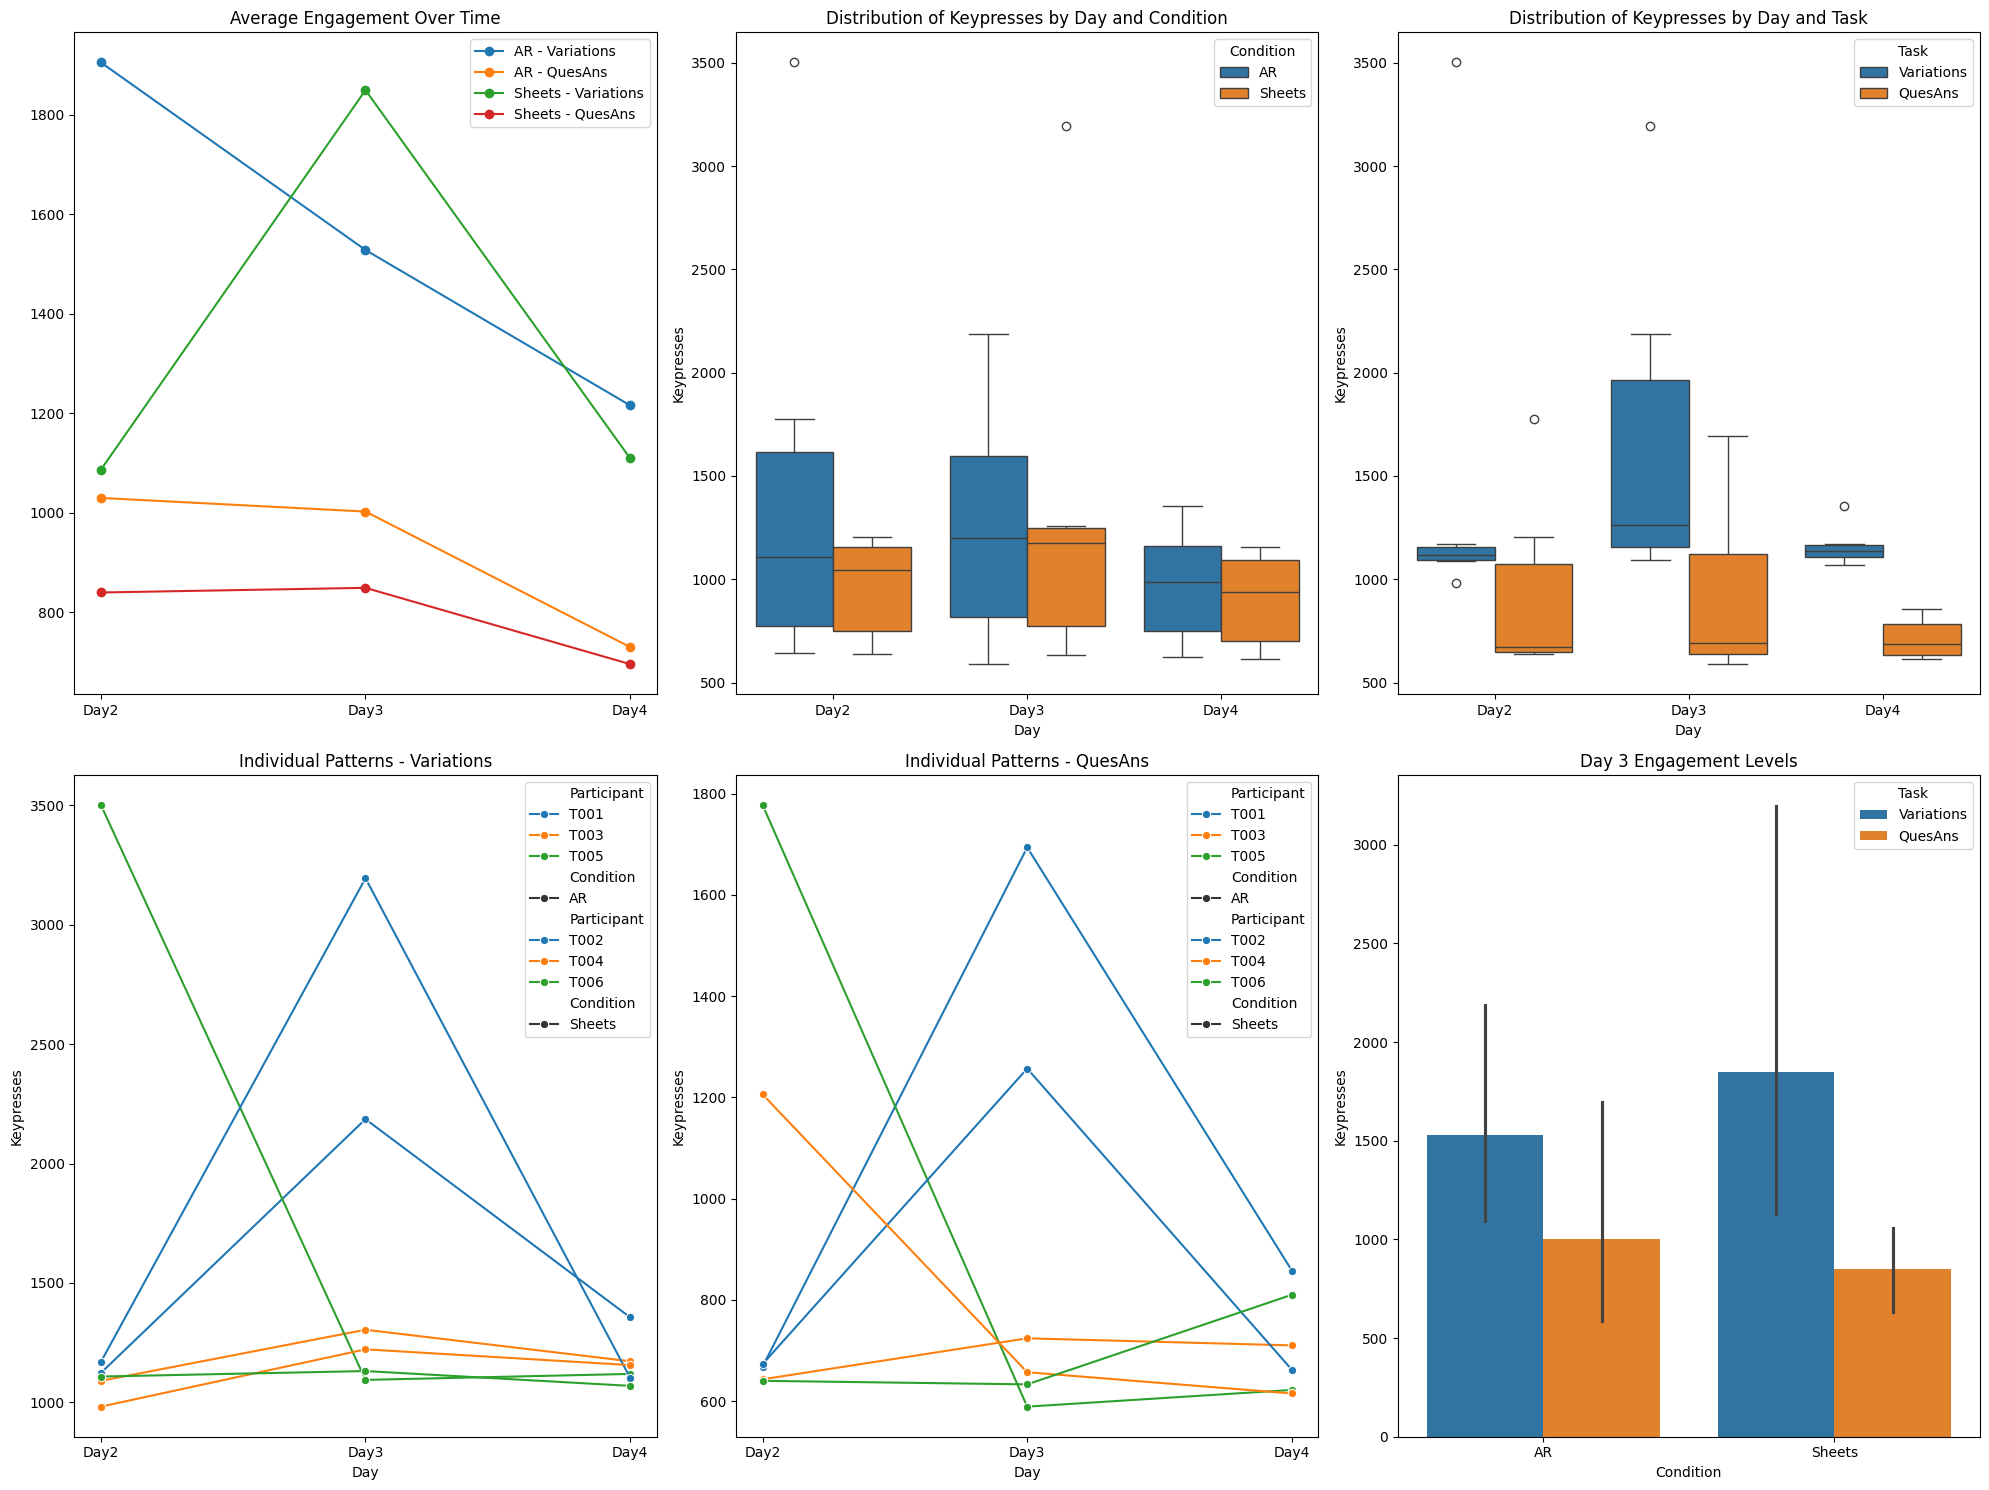

In [2]:

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Create structured data
data = []
for row in [
    # AR Condition Variations
    ('AR', 'Variations', 'T001', 'Day2', 1123), ('AR', 'Variations', 'T001', 'Day3', 2186), ('AR', 'Variations', 'T001', 'Day4', 1356),
    ('AR', 'Variations', 'T003', 'Day2', 1090), ('AR', 'Variations', 'T003', 'Day3', 1304), ('AR', 'Variations', 'T003', 'Day4', 1172),
    ('AR', 'Variations', 'T005', 'Day2', 3502), ('AR', 'Variations', 'T005', 'Day3', 1094), ('AR', 'Variations', 'T005', 'Day4', 1119),
    # Sheets Condition Variations
    ('Sheets', 'Variations', 'T002', 'Day2', 1169), ('Sheets', 'Variations', 'T002', 'Day3', 3195), ('Sheets', 'Variations', 'T002', 'Day4', 1103),
    ('Sheets', 'Variations', 'T004', 'Day2', 982), ('Sheets', 'Variations', 'T004', 'Day3', 1222), ('Sheets', 'Variations', 'T004', 'Day4', 1156),
    ('Sheets', 'Variations', 'T006', 'Day2', 1108), ('Sheets', 'Variations', 'T006', 'Day3', 1131), ('Sheets', 'Variations', 'T006', 'Day4', 1069),
    # AR Condition QuesAns
    ('AR', 'QuesAns', 'T001', 'Day2', 668), ('AR', 'QuesAns', 'T001', 'Day3', 1694), ('AR', 'QuesAns', 'T001', 'Day4', 858),
    ('AR', 'QuesAns', 'T003', 'Day2', 643), ('AR', 'QuesAns', 'T003', 'Day3', 724), ('AR', 'QuesAns', 'T003', 'Day4', 710),
    ('AR', 'QuesAns', 'T005', 'Day2', 1778), ('AR', 'QuesAns', 'T005', 'Day3', 589), ('AR', 'QuesAns', 'T005', 'Day4', 622),
    # Sheets Condition QuesAns
    ('Sheets', 'QuesAns', 'T002', 'Day2', 673), ('Sheets', 'QuesAns', 'T002', 'Day3', 1257), ('Sheets', 'QuesAns', 'T002', 'Day4', 662),
    ('Sheets', 'QuesAns', 'T004', 'Day2', 1206), ('Sheets', 'QuesAns', 'T004', 'Day3', 657), ('Sheets', 'QuesAns', 'T004', 'Day4', 615),
    ('Sheets', 'QuesAns', 'T006', 'Day2', 640), ('Sheets', 'QuesAns', 'T006', 'Day3', 633), ('Sheets', 'QuesAns', 'T006', 'Day4', 810),
]:
    data.append({
        'Condition': row[0],
        'Task': row[1],
        'Participant': row[2],
        'Day': row[3],
        'Keypresses': row[4]
    })

df = pd.DataFrame(data)

# Calculate percentage changes (Day2 to Day4)
def calculate_total_pct_change(group):
    day2_value = group[group['Day'] == 'Day2']['Keypresses'].iloc[0]
    day4_value = group[group['Day'] == 'Day4']['Keypresses'].iloc[0]
    return ((day4_value - day2_value) / day2_value * 100)

pct_changes = df.groupby(['Condition', 'Task', 'Participant']).apply(calculate_total_pct_change)
pct_changes = pct_changes.reset_index()
pct_changes.columns = ['Condition', 'Task', 'Participant', 'Pct_Change']

# Create visualizations
plt.figure(figsize=(20, 15))

# Plot 1: Engagement patterns over three days
plt.subplot(231)
for condition in ['AR', 'Sheets']:
    for task in ['Variations', 'QuesAns']:
        data_subset = df[(df['Condition'] == condition) & (df['Task'] == task)]
        means = data_subset.groupby('Day')['Keypresses'].mean()
        plt.plot(means.index, means.values, marker='o', label=f'{condition} - {task}')
plt.title('Average Engagement Over Time')
plt.legend()

# Plot 2: Distribution of keypresses by day
plt.subplot(232)
sns.boxplot(data=df, x='Day', y='Keypresses', hue='Condition')
plt.title('Distribution of Keypresses by Day and Condition')

# Plot 3: Task comparison across days
plt.subplot(233)
sns.boxplot(data=df, x='Day', y='Keypresses', hue='Task')
plt.title('Distribution of Keypresses by Day and Task')

# Plot 4: Individual trajectories - Variations
plt.subplot(234)
for condition in ['AR', 'Sheets']:
    variations_data = df[(df['Task'] == 'Variations') & (df['Condition'] == condition)]
    sns.lineplot(data=variations_data, x='Day', y='Keypresses',
                hue='Participant', style='Condition', marker='o')
plt.title('Individual Patterns - Variations')

# Plot 5: Individual trajectories - QuesAns
plt.subplot(235)
for condition in ['AR', 'Sheets']:
    quesans_data = df[(df['Task'] == 'QuesAns') & (df['Condition'] == condition)]
    sns.lineplot(data=quesans_data, x='Day', y='Keypresses',
                hue='Participant', style='Condition', marker='o')
plt.title('Individual Patterns - QuesAns')

# Plot 6: Day 3 peak analysis
plt.subplot(236)
sns.barplot(data=df[df['Day'] == 'Day3'], x='Condition', y='Keypresses', hue='Task')
plt.title('Day 3 Engagement Levels')

plt.tight_layout()

# Statistical Analysis
# Calculate statistics by day
stats_by_day = df.groupby(['Condition', 'Task', 'Day']).agg({
    'Keypresses': ['mean', 'std']
}).round(2)

# Friedman test for repeated measures
def run_friedman_test(data, condition, task):
    subset = data[(data['Condition'] == condition) & (data['Task'] == task)]
    pivot_data = subset.pivot(index='Participant', columns='Day', values='Keypresses')
    return stats.friedmanchisquare(pivot_data['Day2'], pivot_data['Day3'], pivot_data['Day4'])

# Print results
print("1. Overall Statistics by Day:")
print(stats_by_day)

print("\n2. Percentage Changes (Day2 to Day4):")
print(pct_changes.groupby(['Condition', 'Task'])['Pct_Change'].agg(['mean', 'std']).round(2))

print("\n3. Statistical Tests (Friedman Test):")
for condition in ['AR', 'Sheets']:
    for task in ['Variations', 'QuesAns']:
        stat, p = run_friedman_test(df, condition, task)
        print(f"{condition} - {task}: p-value = {p:.4f}")

# Calculate Day 3 peak analysis
day3_stats = df[df['Day'] == 'Day3'].groupby(['Condition', 'Task'])['Keypresses'].agg(['mean', 'std']).round(2)
print("\n4. Day 3 Peak Analysis:")
print(day3_stats)
